# ACL_ICWSM_2018

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description

This datasets consist of tweets collected during the 2015 Nepal Earthquake and the 2013 Queensland Flood. The annotation of relevant and irrelevant (not_relevant) categories consist of 11,668 tweets for the Nepal Earthquake dataset and 10,033 tweets for the Queensland dataset.

For each dataset, we also release ids of the tweets of the unlabelled data that we used for our experiments. One can use our Tweet retrieval tool (available on CrisisNLP.qcri.org) to download the tweets based on ids provided in the datasets.

### Data formats
Each .tsv file contains 3 columns separated by tab:
1) id
2) text of the tweet
3) class label. The .txt file contains tweets ids, which are not labeled. 

##### 2015 Nepal Earthquake:
- nepal/2015_Nepal_Earthquake_train.tsv -- 7000 labeled tweets
- nepal/2015_Nepal_Earthquake_dev.tsv  -- 1166 labeled tweets
- nepal/2015_Nepal_Earthquake_test.tsv  -- 3502 labeled tweets
- nepal/2015_Nepal_Earthquake_unlabelled_ids.txt -- 864,966 un-labeled tweet ids


##### 2013 Queensland Flood:
- queensland/2013_Queensland_Floods_train.tsv -- 6019 labeled tweets 
- queensland/2013_Queensland_Floods_dev.tsv -- 1003 labeled tweets 
- queensland/2013_Queensland_Floods_test.tsv -- 3011 labeled tweets
- queensland/2013_Queensland_Floods_unlabelled_ids.txt -- 21,917  un-labeled tweet ids


### Citation information

- Firoj Alam, Shafiq Joty, Muhammad Imran. Domain Adaptation with Adversarial Training and Graph Embeddings. In proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (ACL), 2018, Melbourne, Australia. 

- Firoj Alam, Shafiq Joty, Muhammad Imran. Graph Based Semi-supervised Learning with Convolutional Neural Networks to Classify Crisis Related Tweets, International AAAI Conference on Web and Social Media (ICWSM), 2018, Stanford, California, USA.

## B. Overview

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'ACL_ICWSM_2018' / 'ACL_ICWSM_2018_datasets'

Loading the `2015_Nepal_Earthquake_train.tsv` file

In [2]:
filepath = dataset_path / 'nepal' / '2015_Nepal_Earthquake_train.tsv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

# File contains non-UTF8 bytes, so use latin1.
df = pd.read_csv(filepath, sep='\t', encoding='latin1')

In [3]:
df.head()

,tweet_id,text,label
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,relevant
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,relevant
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,relevant
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,relevant
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,relevant


In [4]:
df[0:1]['tweet_id']

0    591902739002560512
Name: tweet_id, dtype: int64

In [5]:
tsv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(tsv_array[:5])

Loaded 6899 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/ACL_ICWSM_2018/ACL_ICWSM_2018_datasets/nepal/2015_Nepal_Earthquake_train.tsv
[[591902739002560512
  "RT @AnupKaphle: #Nepal's prime minister addressed the country for 1st time since earthquake on Saturday. No concrete plans, lots of referenâ\x80°Ã\x9b_"
  'relevant']
 [592939706788216832
  '@jonsnowC4 So have we; read our friends blog from Lamjung where they are working http://t.co/jGpSacUQpe'
  'relevant']
 [592591542168252416
  'Lend a helping hand if you can #Nepal https://t.co/FdRrvC84EA'
  'relevant']
 [591903009279385600
  "@shilpaanand they've managed to reach Kathmandu but with the help of their guide - not through the official evacuation I believe."
  'relevant']
 [592099765271199744
  'Israel Sending Aid Teams to Nepal After Quake: Israel was sending a delegation to Nepal Saturday to determine ... h

## C. Preprocess

Combine all train, dev, test files from both events to one

In [6]:
import json

files = [
    {
        'filename': 'nepal/2015_Nepal_Earthquake_train.tsv',
        'country': 'Nepal',
        'event_type': 'earthquake',
        'event_name': '2015 Nepal Earthquake',
        'year': 2015,
    },
    {
        'filename': 'nepal/2015_Nepal_Earthquake_dev.tsv',
        'country': 'Nepal',
        'event_type': 'earthquake',
        'event_name': '2015 Nepal Earthquake',
        'year': 2015,
    },
    {
        'filename': 'nepal/2015_Nepal_Earthquake_test.tsv',
        'country': 'Nepal',
        'event_type': 'earthquake',
        'event_name': '2015 Nepal Earthquake',
        'year': 2015,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_train.tsv',
        'country': 'Australia',
        'event_type': 'flood',
        'event_name': '2013 Queensland Floods',
        'year': 2013,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_dev.tsv',
        'country': 'Australia',
        'event_type': 'flood',
        'event_name': '2013 Queensland Floods',
        'year': 2013,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_test.tsv',
        'country': 'Australia',
        'event_type': 'flood',
        'event_name': '2013 Queensland Floods',
        'year': 2013,
    }
]

df_list = []

for file in files:
    filename = file['filename']
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f'Not found: {filepath}')
        continue

    df = pd.read_csv(filepath, sep='\t', encoding='latin1')
    df['event_type'] = file['event_type']
    df['event_name'] = file['event_name']
    df['country'] = file['country']
    df['year'] = file['year']
    df['informative'] = df['label'].apply(lambda x: True if x == 'relevant' else False)
    df.rename(columns={'label': 'original_informative_label'}, inplace=True)
    df['dataset'] = 'ACL_ICWSM_2018'
    df['humanitarian_label'] = np.nan
    df['original_humanitarian_label'] = np.nan
    df.rename(columns={'label': 'original_label'}, inplace=True)
    df['meta'] = json.dumps({'file_name': filename})
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)

merged_df.rename(columns={'text': 'tweet_text'}, inplace=True)
merged_df = merged_df[dataset_settings.dataset_extended_cols]

merged_df.head()

KeyError: "['relevant', 'original_relevant_label'] not in index"

In [ ]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

print(merged_df['tweet_text'].value_counts())

# # Remove duplicates
merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 1014
tweet_text
RT @bravotrav: Tony Abbott is visiting flood affected areas of Queensland today. I'm sure he'll remind Queenslanders he opposed the floo ...    110
RT @newscientist: Climate change blamed as #Australia lurches from fire to flood http://t.co/szxtcw7m #extremeweather                            65
RT @7NewsBrisbane: Foam from rough waves at Alexandra Headland resembles snow on the Sunshine Coast #staysafe #bigwet #queensland #flood ...     58
Daring rescue of teenager from flood waters: Australia reels from surging floods http://t.co/Qe5FcKlW                                            28
RT @AJEnglish: Deadly flood waters rise in eastern Australia http://t.co/UDIcfaPq                                                                26
                                                                                                                                               ... 
Dear God, please stop rocking my world #NepalEarthquake             

tweet_text
RT @AnupKaphle: #Nepal's prime minister addressed the country for 1st time since earthquake on Saturday. No concrete plans, lots of referenâ°Ã_    1
I did absolutely nothing today. Been sleeping, watchin movie and eating. Really made my day.                                                         1
@_aycakck_ thanks for the follow back babes                                                                                                          1
@GesiLorraine Lucky you! It was beautiful. Would love to come back.                                                                                  1
You're the bee's knees but so am i                                                                                                                   1
                                                                                                                                                    ..
Early Headlines:  Latest from Nepal, Video Taken as Avalanche Hit, China&amp;#039;s

In [ ]:
merged_df.duplicated(subset=['tweet_id']).sum()

np.int64(0)

In [ ]:
merged_df.duplicated(subset=['tweet_text']).sum()

np.int64(0)

In [ ]:
import csv
merged_df.to_csv( '../data/datasets/ACL_ICWSM_2018.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifing

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20557 entries, 0 to 21569
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tweet_id                     20557 non-null  int64  
 1   tweet_text                   20557 non-null  object 
 2   relevant                     20557 non-null  bool   
 3   humanitarian_label           0 non-null      float64
 4   event_name                   20557 non-null  object 
 5   event_type                   20557 non-null  object 
 6   dataset                      20557 non-null  object 
 7   original_relevant_label      20557 non-null  object 
 8   original_humanitarian_label  0 non-null      float64
 9   year                         20557 non-null  int64  
 10  meta                         20557 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 1.7+ MB


In [ ]:
merged_df.describe(include='all')

,tweet_id,tweet_text,relevant,humanitarian_label,event_name,event_type,dataset,original_relevant_label,original_humanitarian_label,year,meta
count,2.055700e+04,20557,20557,0.0,20557,20557,20557,20557,0.0,20557.000000,20557
unique,NaN,20557,2,NaN,2,2,1,2,NaN,NaN,6
top,NaN,RT @AnupKaphle: #Nepal's prime minister addres...,False,NaN,2015 Nepal Earthquake,earthquake,ACL_ICWSM_2018,not_relevant,NaN,NaN,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
freq,NaN,1,10667,NaN,11525,11525,20557,10667,NaN,NaN,6892
mean,4.622943e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.121273,NaN
std,1.470233e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.992643,NaN
min,2.953206e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
25%,2.961939e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
50%,5.919030e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN
75%,5.926382e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN


<Axes: xlabel='event_type'>

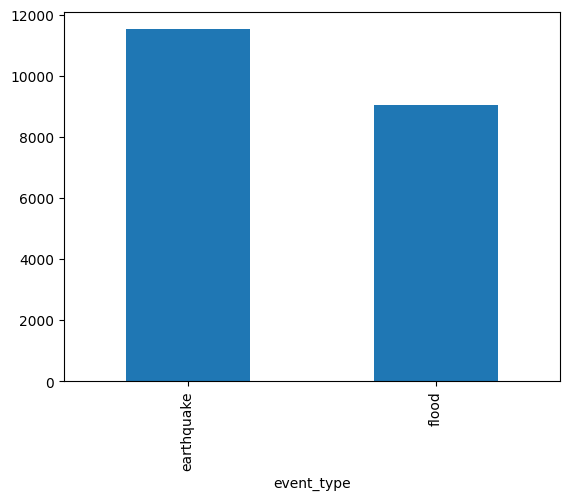

In [ ]:
merged_df['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='informative'>

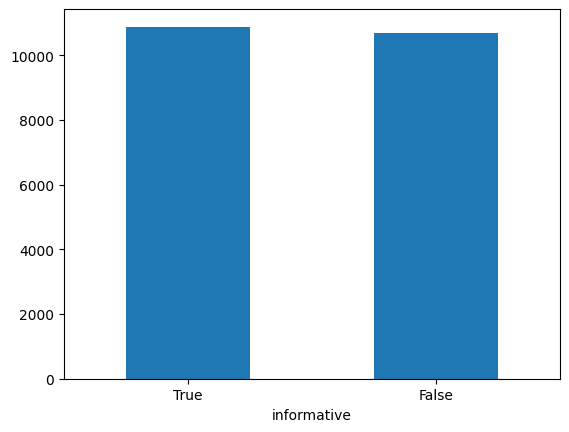

In [7]:
merged_df['informative'].value_counts().plot(kind='bar', rot=0)